In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [87]:
DATA_PATH = 'C:/Users/user/Downloads/archive/Sleep_health_and_lifestyle_dataset.csv'  

df = pd.read_csv(DATA_PATH)
print(f"Загружено {df.shape[0]} строк, {df.shape[1]} столбцов")
df.head()

Загружено 374 строк, 13 столбцов


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [88]:
print('\nИнфо о датасете:')
print(df.info())

print('\nПропуски по столбцам:')
print(df.isna().sum())

print('\nОписательная статистика (числовые признаки):')
print(df.describe().T)


Инфо о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB
None


Числовые признаки: ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']


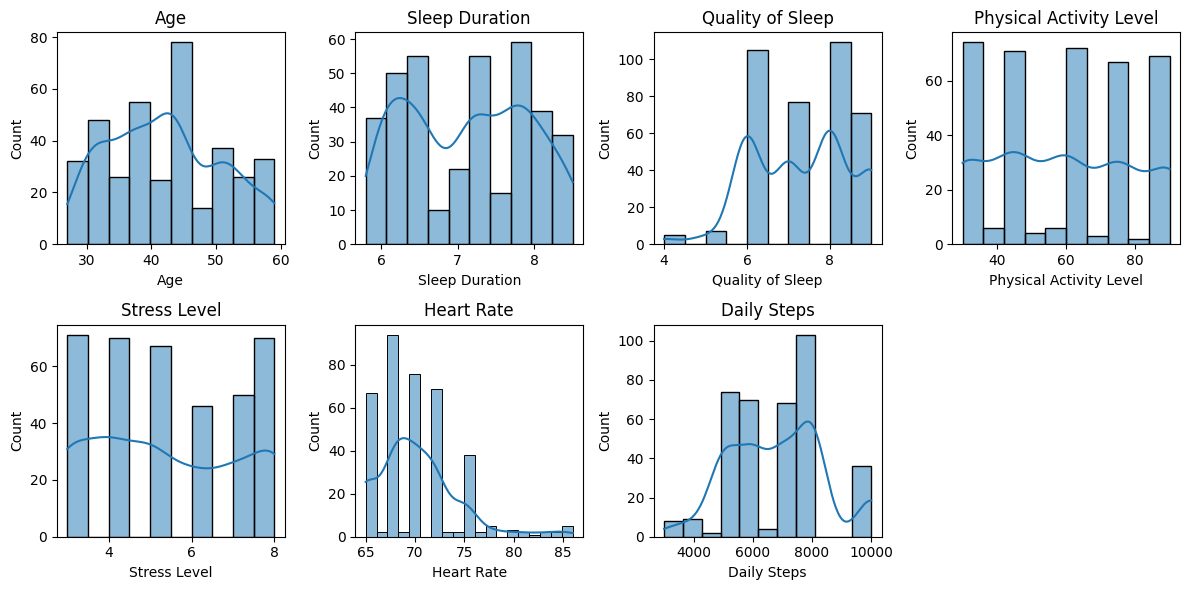

In [89]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Person ID' in num_cols:
    num_cols.remove('Person ID')

print('\nЧисловые признаки:', num_cols)

plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, int(np.ceil(len(num_cols)/2)), i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(col)
plt.tight_layout()

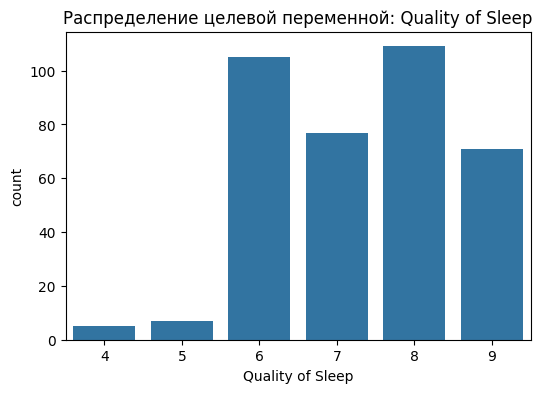

In [90]:
TARGET = 'Quality of Sleep'
if TARGET not in df.columns:
    raise ValueError(f"Целевая колонка '{TARGET}' не найдена в датасете. Измените TARGET в ноутбуке.")

plt.figure(figsize=(6,4))
if df[TARGET].dtype == 'O' or df[TARGET].nunique() < 10:
    sns.countplot(x=TARGET, data=df)  
else:
    sns.histplot(df[TARGET].dropna(), kde=True, bins=10)  
plt.title(f'Распределение целевой переменной: {TARGET}')
plt.show()


In [91]:
df_clean = df.dropna().copy()
print(f"После удаления пропусков: {df_clean.shape[0]} строк")
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()


После удаления пропусков: 155 строк


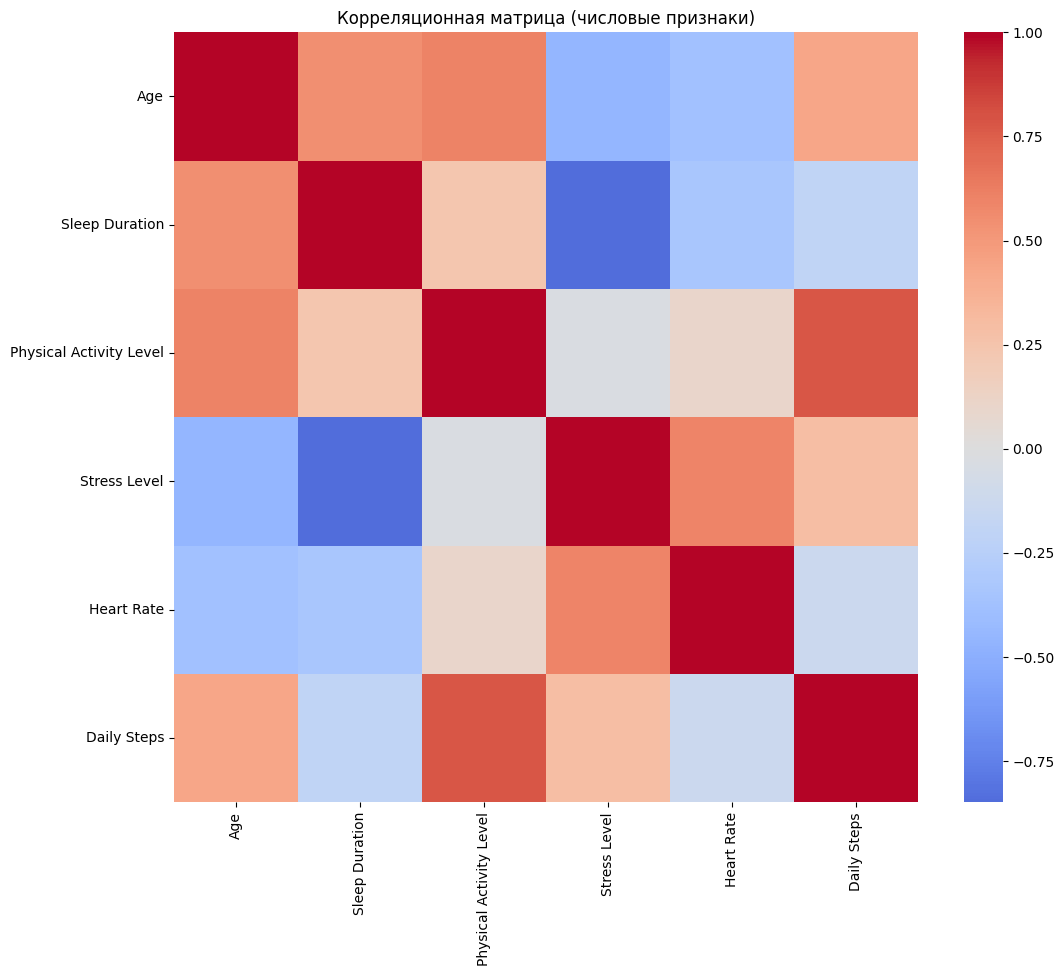


VIF для числовых признаков:
                   feature        VIF
6              Daily Steps  24.555631
3  Physical Activity Level  21.719397
4             Stress Level  13.226342
5               Heart Rate  10.898420
2           Sleep Duration   6.113344
1                      Age   2.724257


In [92]:
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

if 'Person ID' in df_encoded.columns: 
    df_encoded = df_encoded.drop(columns=['Person ID'])

X_all = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

num_X = X_all.select_dtypes(include=[np.number]).copy()


plt.figure(figsize=(12,10))
corr = num_X.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица (числовые признаки)')
plt.show()


X_for_vif = sm.add_constant(num_X)
vif_data = pd.DataFrame()
vif_data['feature'] = X_for_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_for_vif.values, i)
                   for i in range(X_for_vif.shape[1])]


vif_data = vif_data[vif_data['feature'] != 'const'].sort_values(by='VIF', ascending=False)
print('\nVIF для числовых признаков:')
print(vif_data)

In [93]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)


num_cols_X = X_all.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols_X] = scaler.fit_transform(X_train[num_cols_X])
X_test_scaled[num_cols_X] = scaler.transform(X_test[num_cols_X])


Train shape: (124, 33) Test shape: (31, 33)


In [94]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [95]:
def mape(y_true, y_pred):

    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

In [96]:

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lin = LinearRegression()
cv_mse = -cross_val_score(lin, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
print('CV RMSE (Линейная регрессия) mean:', np.sqrt(cv_mse).mean())


lin.fit(X_train_scaled, y_train)
y_pred_lin = lin.predict(X_test_scaled)

print('\nЛинейная регрессия (test):')
print('RMSE:', rmse(y_test, y_pred_lin))
print('R2:', r2_score(y_test, y_pred_lin))
print('MAPE (%):', mape(y_test, y_pred_lin))

CV RMSE (Линейная регрессия) mean: 0.4547135306761885

Линейная регрессия (test):
RMSE: 0.08887634408494884
R2: 0.995481581332781
MAPE (%): 0.5186226996308437


In [97]:
ridge = Ridge()
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

gs = GridSearchCV(ridge, param_grid, scoring='neg_mean_squared_error', cv=kf)
gs.fit(X_train_scaled, y_train)
print('\nЛучший alpha для Гребневой регрессии:', gs.best_params_)

ridge_best = gs.best_estimator_
cv_mse_ridge = -cross_val_score(ridge_best, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
print('CV RMSE (Гребневая) mean:', np.sqrt(cv_mse_ridge).mean())

ridge_best.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_best.predict(X_test_scaled)

print('\nГребневая регрессия (test):')
print('RMSE:', rmse(y_test, y_pred_ridge))
print('R2:', r2_score(y_test, y_pred_ridge))
print('MAPE (%):', mape(y_test, y_pred_ridge))


Лучший alpha для Гребневой регрессии: {'alpha': 1}
CV RMSE (Гребневая) mean: 0.24346848640388608

Гребневая регрессия (test):
RMSE: 0.306184020761609
R2: 0.9463735374752825
MAPE (%): 2.7278144352204348


Число компонент для 95% объяснённой дисперсии: 8


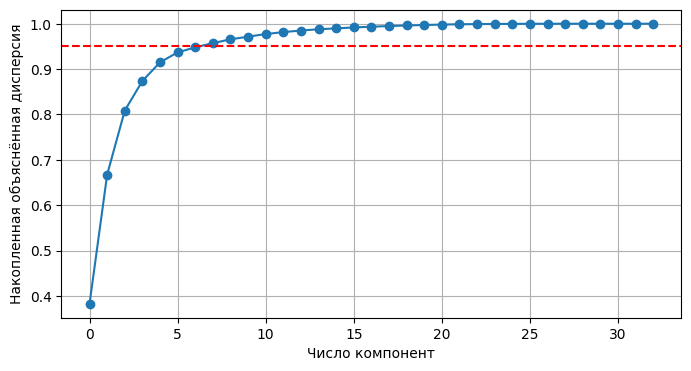

In [98]:

X_scaled_all = X_all.copy()
X_scaled_all[num_cols_X] = scaler.transform(X_all[num_cols_X])


pca = PCA()
X_pca = pca.fit_transform(X_scaled_all)

explained_cum = np.cumsum(pca.explained_variance_ratio_)


n_components_95 = np.searchsorted(explained_cum, 0.95) + 1
print('Число компонент для 95% объяснённой дисперсии:', n_components_95)


plt.figure(figsize=(8,4))
plt.plot(explained_cum, marker='o')
plt.axhline(0.95, color='r', linestyle='--')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.grid()
plt.show()

In [99]:
N_PCA = n_components_95
pca_final = PCA(n_components=N_PCA)
X_pca_final = pca_final.fit_transform(X_scaled_all)


pca_cols = [f'PC{i+1}' for i in range(N_PCA)]
df_pca = pd.DataFrame(X_pca_final, columns=pca_cols, index=X_all.index)

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
3,-4.221918,0.379578,2.236011,-1.035384,0.409641,-0.276864,0.597714,0.075196
4,-4.221918,0.379578,2.236011,-1.035384,0.409641,-0.276864,0.597714,0.075196
5,-4.365270,0.224921,2.033801,-0.848779,0.365238,0.104828,0.067854,-0.478317
6,-3.511193,-0.258098,1.716476,-1.104919,-0.091024,0.417365,0.244615,-0.228966
16,-2.645218,0.097144,1.648966,-1.366116,0.112308,-1.361592,-0.428176,-0.446909


In [100]:

X_train_pca = df_pca.loc[X_train.index]
X_test_pca = df_pca.loc[X_test.index]

lin_pca = LinearRegression()
cv_mse_lin_pca = -cross_val_score(lin_pca, X_train_pca, y_train, cv=kf, scoring='neg_mean_squared_error')
print('CV RMSE (Linear on PCA) mean:', np.sqrt(cv_mse_lin_pca).mean())

lin_pca.fit(X_train_pca, y_train)
y_pred_lin_pca = lin_pca.predict(X_test_pca)

print('\nLinear Regression on PCA (test):')
print('RMSE:', rmse(y_test, y_pred_lin_pca))
print('R2:', r2_score(y_test, y_pred_lin_pca))
print('MAPE (%):', mape(y_test, y_pred_lin_pca))


ridge = Ridge()
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

gs_pca = GridSearchCV(ridge, param_grid, scoring='neg_mean_squared_error', cv=kf)
gs_pca.fit(X_train_pca, y_train)
print('\nЛучший alpha для Ridge (PCA):', gs_pca.best_params_)

ridge_best_pca = gs_pca.best_estimator_
cv_mse_ridge_pca = -cross_val_score(ridge_best_pca, X_train_pca, y_train, cv=kf, scoring='neg_mean_squared_error')
print('CV RMSE (Ridge on PCA) mean:', np.sqrt(cv_mse_ridge_pca).mean())

ridge_best_pca.fit(X_train_pca, y_train)
y_pred_ridge_pca = ridge_best_pca.predict(X_test_pca)

print('\nRidge Regression on PCA (test):')
print('RMSE:', rmse(y_test, y_pred_ridge_pca))
print('R2:', r2_score(y_test, y_pred_ridge_pca))
print('MAPE (%):', mape(y_test, y_pred_ridge_pca))

CV RMSE (Linear on PCA) mean: 0.2691306127942751

Linear Regression on PCA (test):
RMSE: 0.2903094225612145
R2: 0.9517900845502735
MAPE (%): 3.042196381899149

Лучший alpha для Ridge (PCA): {'alpha': 1}
CV RMSE (Ridge on PCA) mean: 0.26805239624144667

Ridge Regression on PCA (test):
RMSE: 0.28873015672240143
R2: 0.9523131759712465
MAPE (%): 3.024811239819197


In [101]:
results = pd.DataFrame({
    'model': ['Линейная', 'Гребневая', 'Линейная_PCA', 'Гребневая_PCA'],
    'RMSE': [rmse(y_test, y_pred_lin), rmse(y_test, y_pred_ridge), rmse(y_test, y_pred_lin_pca), rmse(y_test, y_pred_ridge_pca)],
    'R2': [r2_score(y_test, y_pred_lin), r2_score(y_test, y_pred_ridge), r2_score(y_test, y_pred_lin_pca), r2_score(y_test, y_pred_ridge_pca)],
    'MAPE (%)': [mape(y_test, y_pred_lin), mape(y_test, y_pred_ridge), mape(y_test, y_pred_lin_pca), mape(y_test, y_pred_ridge_pca)]
})

print(results)


results.to_csv('C:/Users/user/Downloads/archive/regression_comparison_results.csv', index=False)
print('\nРезультаты сохранены в regression_comparison_results.csv')

           model      RMSE        R2  MAPE (%)
0       Линейная  0.088876  0.995482  0.518623
1      Гребневая  0.306184  0.946374  2.727814
2   Линейная_PCA  0.290309  0.951790  3.042196
3  Гребневая_PCA  0.288730  0.952313  3.024811

Результаты сохранены в regression_comparison_results.csv
